# Project INFO-H-512 
## Data Attribution for Credit-Risk Models: A BoostIn-Based Approach to GBDT Explanation
### Group members: 
+ GUELENNE Zoé 
+ LARDAU Clara 
+ Nguyen Thanh 

## 0. Imports

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import (train_test_split, StratifiedKFold, RandomizedSearchCV)
import lightgbm
from lightgbm import LGBMClassifier
from tree_influence.explainers import BoostIn
import pandas as pd 
import sklearn 
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    fbeta_score,
    make_scorer,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    roc_curve
)
import re
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore", category=UserWarning,
                        module="sklearn")
import shap
import time 
from sklearn.metrics import log_loss 
from sklearn.base import clone
from scipy.stats import spearmanr


/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Preparation
The German credit dataset was chosen for this analysis (find the dataset [here](https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk)). In this dataset, each entry represents a person who takes a credit by a bank. Each person is classified as good or bad credit risks according to the set of attributes.

### 1.1 Data Loading and Descriptive Analysis

In [2]:
# load german credit data 
data = pd.read_csv('german_credit_data.csv', index_col=0)

# check data type 
print("======= Data types =======")
print(data.dtypes)

# brief summary of integers 
print("\n======= Data summary =======")
print(data.describe())

# brief summary for categorical variables 
print("\n======= Categorical value counts =======")
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols: 
    counts = data[col].value_counts(dropna=False).to_frame(name='count')
    counts['%'] = (counts['count']/len(data)*100).round(1)
    print(f"\n--- {col} ---")
    print(counts)

# count NaN 
print("\n======= NaN count =======")
nan_count = data.isna().sum()
print(nan_count)

======= Data types =======
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

======= Data summary =======
               Age          Job  Credit amount     Duration
count  1000.000000  1000.000000    1000.000000  1000.000000
mean     35.546000     1.904000    3271.258000    20.903000
std      11.375469     0.653614    2822.736876    12.058814
min      19.000000     0.000000     250.000000     4.000000
25%      27.000000     2.000000    1365.500000    12.000000
50%      33.000000     2.000000    2319.500000    18.000000
75%      42.000000     2.000000    3972.250000    24.000000
max      75.000000     3.000000   18424.000000    72.000000

======= Categorical value counts =======

--- Sex ---
        count     %
Sex                
male      690  69.0
fema

Regarding data types, it seems that categorical variables have the `object` type. This should be changed to the `category` type so that LightGBM can handle them. Categorical variables won't be one-hot-encoded as LightGBM can handle them.

The brieve descriptive analysis on numerical data reveals that there is not a strong presence of outliers as the mean is close to the median. 

The brieve descriptive analysis on categorical variables reveals that $30\%$ of the dataset is flagged as bad credit risk. the target variable `Risk`should be mapped to binary values: $0$ for `good`and $1$ for `bad`. 

The NaN count reveals that `Saving accounts` and `Checking account` contains NaN values. However, as LightGBM handles NaN values natively (see [LightGBM documentation](https://lightgbm.readthedocs.io/en/v3.3.2/Advanced-Topics.html)), no imputation will be performed in data preprocessing steps. 

### 1.2 Data Preprocessing

In [3]:
# categorical columns have type 'object', should transform in category pandas dtype for LightGBM
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
for c in cat_cols: 
    data[c] = data[c].astype('category')
    
# binary encoding for target value 
data["Risk"] = data["Risk"].map({'good': 0, 'bad': 1}).astype(int) #small code adjustement with map to avoid errors

# prepare target and features datasets 
y = data["Risk"]
X = data.drop(columns="Risk").copy()

# BoostIn will require numpy afterwards 
for c in cat_cols: 
    X[c] = X[c].cat.codes 
    X[c] = X[c].astype('float').replace(-1, np.nan)

cat_idx = [X.columns.get_loc(c) for c in cat_cols]

## 2. Model

### 2.1 Model Training and Evaluation with Baseline Hyperparameters 

### A. Functions 

In [4]:
def compute_model_metrics(y_true, y_pred, y_proba):
    scores = {k: [] for k in ["accuracy", "recall", "precision", "f1", "f2", "roc_auc", "pr_auc"]}
    scores["accuracy"].append(accuracy_score(y_true, y_pred))
    scores["recall"].append(recall_score(y_true, y_pred))
    scores["precision"].append(precision_score(y_true, y_pred))
    scores["f1"].append(f1_score(y_true, y_pred))
    scores["f2"].append(fbeta_score(y_true, y_pred, beta=2))
    scores["roc_auc"].append(roc_auc_score(y_true, y_proba))
    scores["pr_auc"].append(average_precision_score(y_true, y_proba))
    return scores

### B. Pipeline

In [5]:
# Train and evaluate model in CV (k=5)

cv = StratifiedKFold(
    n_splits=5, 
    shuffle=True, 
    random_state=42
)

scores = {k: [] for k in ["accuracy", "recall", "precision", "f1", "f2", "roc_auc", "pr_auc"]}

for train_idx, val_idx in cv.split(X,y): 
    X_train, X_test = X.iloc[train_idx].to_numpy(), X.iloc[val_idx].to_numpy()
    y_train, y_test = y.iloc[train_idx].to_numpy(), y.iloc[val_idx].to_numpy()

    model = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced').fit(X_train, y_train, categorical_feature=cat_idx)
    y_hat = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] # predicted proba of belonging to bad class -> take second column

    fold_scores = compute_model_metrics(y_test, y_hat, y_proba)
    
    for name, val in fold_scores.items():
        scores[name].append(val[0] if isinstance(val, list) else val)

results=pd.DataFrame(scores)
summary = results.agg(['mean', 'std']).T            
summary.columns = ['Mean', 'Std']
summary = summary.round(3)
print("======= Performance in CV (k=5) =======")
print(summary)

======= Performance in CV (k=5) =======
            Mean    Std
accuracy   0.714  0.023
recall     0.537  0.030
precision  0.524  0.037
f1         0.530  0.032
f2         0.534  0.030
roc_auc    0.739  0.020
pr_auc     0.577  0.021


## 2.2 Finetuning 
Regarding hyperparameters finetuning, the focus was on the ones recommanded by [LightGBM documentation](https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html): `num_leaves` (to control complexity), `max_depth` (also for complexity, must be careful that `num_leaves` <= `max_depth`) and `min_child_samples` (to control for overfitting). 

Hyperparameters are finetuned to optimise the F2-score as the model is dealing with a credit-risk detection problematic. In such settings, missclassifying a bad debtor as a good one costs more to an institution, meaning that recall, the true positive rate, is an important metric. F2-score is defined as the harmonic mean between precision and recall, giving twice as much importance to recall as to precision and is therefore a good candidate for optimisation. 

In [6]:
# fixed held-out split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

hyper_param_grid = {
    "num_leaves": [7,15,31,63], # LightGBM doc -> num_leaves <= 2^max_depth
    "max_depth": [3,4,5,6,-1], 
    "min_child_samples": [5,10,20,50,100],
}
# define model to pass through RandomizedGridSearch
model_for_grid = LGBMClassifier(
    random_state=42, 
    verbose=-1, 
    force_col_wise=True,
    class_weight='balanced'
)

# define parameters of CV 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
randomized_grid_search = RandomizedSearchCV(
    estimator=model_for_grid,
    param_distributions=hyper_param_grid,
    scoring=make_scorer(fbeta_score, beta=2),
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=0,
    return_train_score=True,
    refit=True
)

# fit only on training data
randomized_grid_search.fit(
    X_train,
    y_train,
    categorical_feature=cat_idx
)

print("Best params:", randomized_grid_search.best_params_)
print("Best CV F2:", round(randomized_grid_search.best_score_, 3))

# keep best model for rest of pipeline
fitted_model = randomized_grid_search.best_estimator_


Best params: {'num_leaves': 63, 'min_child_samples': 100, 'max_depth': 4}
Best CV F2: 0.661


### 2.3 Model Evaluation with Finetuned Hyperparameters 
Best hyperparameters are passed through the model. The model is fit on the whole training set and evaluated on the hold-out set. ROC and PR curves are plotted.

#### A. Functions

In [7]:
def plot_curves(y_true, y_pred):
        roc_auc = roc_auc_score(y_true, y_pred)
        pr_auc = average_precision_score(y_true, y_pred)

        # ROC curve 
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # PR curve 
        precision, recall, threshold = precision_recall_curve(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve")
        plt.legend()
        plt.tight_layout()
        plt.show()

#### B. Pipeline

In [8]:
bad_class_idx = list(fitted_model.classes_).index(1)

y_hat_test = fitted_model.predict(X_test)
y_proba_test = fitted_model.predict_proba(X_test)[:,bad_class_idx]
y_hat_train = fitted_model.predict(X_train)
y_proba_train = fitted_model.predict_proba(X_train)[:,bad_class_idx]

print("======= Performance on Training Set =======")
scores_train = compute_model_metrics(y_train, y_hat_train, y_proba_train)
results_train = pd.DataFrame(scores_train)
print(results_train)

print("\n======= Performance on Validation Set =======")
scores_val = compute_model_metrics(y_test, y_hat_test, y_proba_test)
results_val = pd.DataFrame(scores_val)
print(results_val)

======= Performance on Training Set =======
   accuracy  recall  precision        f1        f2   roc_auc   pr_auc
0     0.775   0.775   0.596154  0.673913  0.731132  0.858988  0.72856

======= Performance on Validation Set =======
   accuracy    recall  precision        f1        f2   roc_auc    pr_auc
0     0.695  0.666667   0.493827  0.567376  0.623053  0.745833  0.585405


Performances on training and validation shows that the model generalises sufficently well on new data, even though performances are lower than with the training set. 

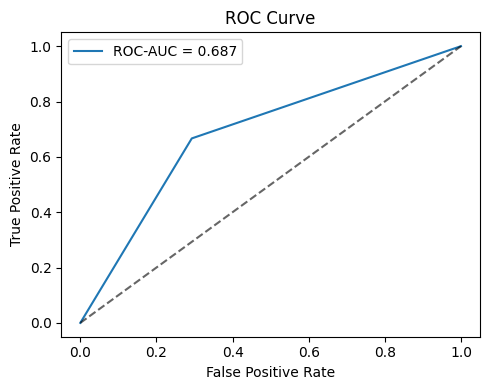

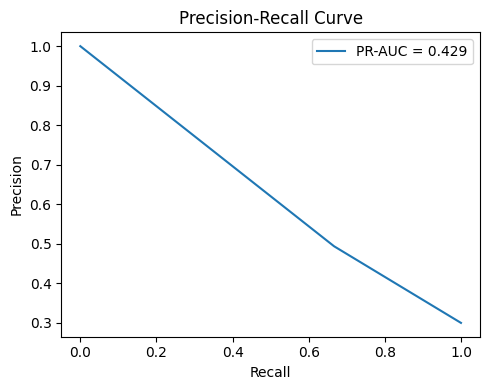

In [9]:
plot_curves(y_test, y_hat_test)

## 3. Leave-One-Out Baseline

In [17]:
# --- Original losses for ALL test applicants ---
base_proba = fitted_model.predict_proba(X_test)
classes = pd.Index(fitted_model.classes_)
y_test_array = np.array(y_test)

# position of the true class for each test applicant
true_class_positions = classes.get_indexer(y_test_array)

# probability assigned to the true class
base_true_proba = base_proba[np.arange(len(y_test)), true_class_positions]

# individual log loss for each test applicant
base_losses = -np.log(base_true_proba)

# --- LOO for all test applicants ---
loo_results = []
start = time.time()

for train_idx in X_train.index:
    
    # remove one training example
    X_train_minus = X_train.drop(index=train_idx)
    y_train_minus = y_train.drop(index=train_idx)
    
    # retrain model
    loo_model = clone(fitted_model)
    loo_model.fit(X_train_minus, y_train_minus)
    
    # predict probabilities for ALL test applicants
    proba_minus = loo_model.predict_proba(X_test)
    
    # probability assigned to the true class for each test applicant
    minus_true_proba = proba_minus[np.arange(len(y_test)), true_class_positions]
    
    # individual log losses after removing train_idx
    losses_minus = -np.log(minus_true_proba)
    
    # LOO scores for all test applicants
    loo_scores = losses_minus - base_losses
    
    # store one row
    row = pd.Series(loo_scores, index=X_test.index, name=train_idx)
    loo_results.append(row)

end = time.time()

loo_df = pd.DataFrame(loo_results)

print("LOO runtime:", end - start, "seconds")
print("Shape:", loo_df.shape)
display(loo_df.head())

LOO runtime: 49.56886887550354 seconds
Shape: (800, 200)


,30,128,289,216,966,346,537,47,112,875,...,64,355,22,579,96,522,977,52,542,423
828,-0.050201,0.155417,-0.031205,0.079056,-0.174641,0.005989,-0.061347,-0.074063,0.297646,0.016850,...,-0.047624,-0.035098,-0.099900,-0.400134,-0.092503,-0.007958,-0.087467,-0.073806,0.091108,0.001125
997,-0.061824,0.102305,-0.008115,0.011092,-0.107562,0.042066,-0.015114,-0.092096,0.187550,0.024395,...,-0.081848,-0.015059,-0.051881,-0.506205,-0.068680,-0.018176,-0.078733,-0.051656,0.034568,-0.044372
148,-0.059871,0.145683,0.005027,0.012476,-0.063878,-0.008458,0.007055,-0.073460,0.337393,0.040604,...,-0.072832,-0.013980,-0.087560,-0.432236,-0.084192,-0.019167,-0.070400,-0.043676,-0.050851,-0.009797
735,-0.086197,0.136211,-0.007437,0.009591,-0.190493,0.058022,-0.039427,0.039276,0.179937,0.070458,...,-0.072556,-0.013143,-0.071337,-0.478981,-0.081302,-0.017815,-0.108480,-0.039303,-0.001464,-0.034972
130,-0.077673,0.192396,0.006644,0.005602,-0.189477,0.046127,-0.130383,-0.114455,0.220947,0.046717,...,-0.045988,-0.007428,-0.066966,-0.422737,-0.088431,-0.019485,-0.106968,-0.049348,-0.016216,-0.013081


We can have an idea of what are the most influencial data points for a precise test point by using the cell below:

In [19]:
target_idx = X_test.index[0]

top_supporters = (
    loo_df[target_idx]
    .sort_values(ascending=False)
    .head(10)
    .rename(f"loo_score_{target_idx}")
    .to_frame()
)

top_opponents = (
    loo_df[target_idx]
    .sort_values(ascending=True)
    .head(10)
    .rename(f"loo_score_{target_idx}")
    .to_frame()
)

top_supporters.index.name = "remove_train_idx"
top_opponents.index.name = "remove_train_idx"

print("Top supporters:")
display(top_supporters)

print("Top opponents:")
display(top_opponents)

Top supporters:


,loo_score_30
remove_train_idx,
626,0.028336
401,0.025691
531,0.019588
868,0.017328
424,0.013912
879,0.011783
240,0.010647
567,0.008847
687,0.008375


Top opponents:


,loo_score_30
remove_train_idx,
726,-0.163992
641,-0.159170
124,-0.153827
864,-0.153626
540,-0.151651
74,-0.148673
278,-0.147147
63,-0.145514
226,-0.144317


## 4. BoostIn custom implementation
Instead of retraining the model like LOO, we look inside the trained GBT and ask: How often does a training applicant follow the same tree paths as the target applicant? To do so, we use BoostIn where we sum influence over trees and a training only contributes at a tree if it lands in the same leaf as the target point. 

In [20]:
start = time.time()
#1: Get leaf index for every train and test applicant 

leaf_train = fitted_model.predict(X_train, pred_leaf= True)
leaf_test =  fitted_model.predict(X_test, pred_leaf= True)

# print("leaf_train shape:", leaf_train.shape)
# print("leaf_test shape:", leaf_test.shape)


In [21]:
#2: Count same-leaf matches between each train applicant and each test applicant 
n_train = leaf_train.shape[0]
n_test = leaf_test.shape[0]
n_trees = leaf_train.shape[1]

same_leaf_count = np.zeros((n_train, n_test))

for t in range(n_trees):
    same_leaf_count += (leaf_train[:, [t]] == leaf_test[:, t])


In [22]:
#3: Compute predicted probabilities
proba_train = fitted_model.predict_proba(X_train)
proba_test = fitted_model.predict_proba(X_test)

# Use the second class as the "positive" class
positive_class = fitted_model.classes_[1]

print("Classes:", fitted_model.classes_)
print("Positive class used:", positive_class)

# Probability of positive class
p_train = proba_train[:, 1]
p_test = proba_test[:, 1]

# Convert true labels to 0/1
y_train_binary = (y_train == positive_class).astype(int).to_numpy()
y_test_binary = (y_test == positive_class).astype(int).to_numpy()

# Gradient of binary log loss with respect to model score
grad_train = p_train - y_train_binary
grad_test = p_test - y_test_binary

Classes: [0 1]
Positive class used: 1


In [23]:
#4 BoostIn style influence score 
boostin_scores = same_leaf_count * (grad_train[:, None] * grad_test[None, :])

boostin_df = pd.DataFrame(
    boostin_scores,
    index=X_train.index,
    columns=X_test.index
)

end = time.time()

print("BoostIn-style runtime:", end - start, "seconds")
print("Shape:", boostin_df.shape)
display(boostin_df.head())

BoostIn-style runtime: 5.0376808643341064 seconds
Shape: (800, 200)


,30,128,289,216,966,346,537,47,112,875,...,64,355,22,579,96,522,977,52,542,423
828,-1.276201,-0.000000,1.653502,-1.269515,2.309083,-0.000000,-1.841018,-0.000000,-6.024679,-0.600740,...,-0.000000,0.000000,-1.317410,-0.000000,-0.942651,4.156330,-2.123202,-0.000000,10.107517,-0.000000
997,0.425887,0.958023,-1.706400,0.484178,-0.097851,3.774517,0.438839,0.436529,0.176749,1.420515,...,0.419227,-0.421064,1.130501,2.435927,0.940272,-0.000000,0.657933,1.565347,-0.000000,1.218824
148,1.544383,0.347406,-4.519839,18.189702,-5.464441,0.399217,9.357140,0.554041,19.740998,0.000000,...,2.979657,-0.400810,2.231953,2.061112,0.701994,-4.807652,1.027749,0.134694,-33.549308,1.485049
735,3.514517,1.581166,-0.000000,6.992210,-9.891716,1.589855,8.872428,4.412866,5.870767,1.323498,...,3.027114,-0.988123,0.181400,0.586303,1.357885,-0.000000,3.800591,0.076630,-14.580229,1.408121
130,2.173254,2.444343,-0.000000,1.152997,-10.874116,1.560492,3.135085,6.497051,10.873291,2.182412,...,1.996652,-1.566719,0.000000,1.208498,1.317127,-2.941444,3.213883,0.105300,-15.663991,0.193496


In [24]:
#5. Compare with LOO

target_idx = X_test.index[0]

loo_top10 = loo_df[target_idx].sort_values(ascending=False).head(10)
boostin_top10 = boostin_df[target_idx].sort_values(ascending=False).head(10)

print("LOO top supporters:")
display(loo_top10.rename("loo_score").to_frame())

print("BoostIn top supporters:")
display(boostin_top10.rename("boostin_score").to_frame())

LOO top supporters:


,loo_score
626,0.028336
401,0.025691
531,0.019588
868,0.017328
424,0.013912
879,0.011783
240,0.010647
567,0.008847
687,0.008375
5,0.008149


BoostIn top supporters:


,boostin_score
785,15.781243
876,13.641545
98,13.568127
360,13.177802
703,12.623370
704,11.554822
530,10.671651
239,10.400641
464,9.369163
410,9.255279


In [25]:
#Similarity Check
k = 10

loo_topk = set(
    loo_df[target_idx]
    .sort_values(ascending=False)
    .head(k)
    .index
)

boostin_topk = set(
    boostin_df[target_idx]
    .sort_values(ascending=False)
    .head(k)
    .index
)

overlap = loo_topk.intersection(boostin_topk)

print("LOO top-k:", loo_topk)
print("BoostIn top-k:", boostin_topk)
print("Common influential points:", overlap)
print("Top-k overlap:", len(overlap) / k)

#Spearman correlation
rho = spearmanr(
    loo_df[target_idx],
    boostin_df[target_idx]
).correlation

print("Spearman correlation:", rho)

LOO top-k: {868, 5, 424, 879, 240, 401, 626, 531, 687, 567}
BoostIn top-k: {704, 98, 360, 876, 239, 464, 785, 530, 410, 703}
Common influential points: set()
Top-k overlap: 0.0
Spearman correlation: -0.006375819898901003


### 5. Overall summary accross indices 

In [26]:
def topk_overlap(a, b, k=10, ascending=False):
    top_a = set(a.sort_values(ascending=ascending).head(k).index)
    top_b = set(b.sort_values(ascending=ascending).head(k).index)
    return len(top_a & top_b) / k

comparison_results = []

k = 10

for target_idx in X_test.index:
    
    loo_scores = loo_df[target_idx]
    boostin_scores = boostin_df[target_idx]
    
    # Spearman rank correlation
    rho = spearmanr(loo_scores, boostin_scores).correlation
    
    # Top supporters: highest positive influence
    supporter_overlap = topk_overlap(
        loo_scores,
        boostin_scores,
        k=k,
        ascending=False
    )
    
    # Top opponents: most negative influence
    opponent_overlap = topk_overlap(
        loo_scores,
        boostin_scores,
        k=k,
        ascending=True
    )
    
    # Most influential in absolute value
    loo_abs_top = set(loo_scores.abs().sort_values(ascending=False).head(k).index)
    boostin_abs_top = set(boostin_scores.abs().sort_values(ascending=False).head(k).index)
    absolute_overlap = len(loo_abs_top & boostin_abs_top) / k
    
    # Sign agreement
    sign_agreement = np.mean(np.sign(loo_scores) == np.sign(boostin_scores))
    
    comparison_results.append({
        "target_idx": target_idx,
        "spearman": rho,
        f"top{k}_supporter_overlap": supporter_overlap,
        f"top{k}_opponent_overlap": opponent_overlap,
        f"top{k}_absolute_overlap": absolute_overlap,
        "sign_agreement": sign_agreement
    })

comparison_df = pd.DataFrame(comparison_results).set_index("target_idx")
overview = comparison_df.mean(numeric_only=True).to_frame("average_score")
display(overview)
# display(comparison_df.head())
# display(comparison_df.describe())

,average_score
spearman,0.033019
top10_supporter_overlap,0.077500
top10_opponent_overlap,0.149000
top10_absolute_overlap,0.083000
sign_agreement,0.466475


In [27]:
display(
    comparison_df.sort_values("spearman", ascending=False).head(10)
)

,spearman,top10_supporter_overlap,top10_opponent_overlap,top10_absolute_overlap,sign_agreement
target_idx,,,,,
683,0.177828,0.3,0.0,0.0,0.28125
570,0.174791,0.0,0.2,0.2,0.65000
818,0.163081,0.3,0.1,0.0,0.26500
854,0.162757,0.1,0.0,0.0,0.27875
671,0.162223,0.1,0.1,0.1,0.26875
887,0.151389,0.0,0.0,0.0,0.31875
236,0.148725,0.2,0.0,0.0,0.26875
992,0.147456,0.1,0.2,0.0,0.32875
801,0.139653,0.0,0.2,0.0,0.68125


In [28]:
display(
    comparison_df.sort_values("spearman", ascending=True).head(10)
)

,spearman,top10_supporter_overlap,top10_opponent_overlap,top10_absolute_overlap,sign_agreement
target_idx,,,,,
724,-0.121536,0.1,0.0,0.0,0.29125
21,-0.101105,0.0,0.1,0.0,0.54000
412,-0.094010,0.0,0.0,0.0,0.28625
485,-0.092128,0.1,0.1,0.0,0.63375
947,-0.085306,0.0,0.0,0.0,0.69375
259,-0.076203,0.0,0.2,0.2,0.26500
46,-0.075876,0.0,0.3,0.3,0.32000
532,-0.070643,0.0,0.2,0.1,0.28375
477,-0.070158,0.0,0.2,0.0,0.64125


<Axes: >

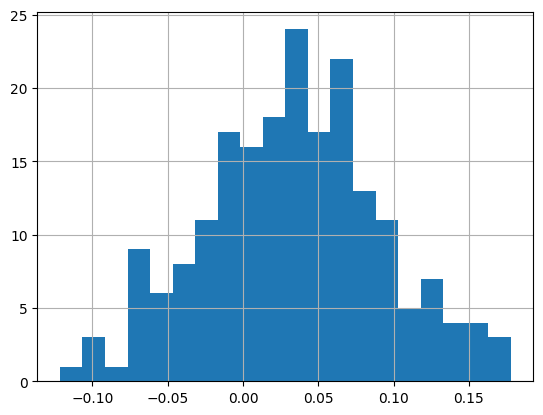

In [29]:
comparison_df["spearman"].hist(bins=20)

array([[<Axes: title={'center': 'top10_supporter_overlap'}>,
        <Axes: title={'center': 'top10_opponent_overlap'}>],
       [<Axes: title={'center': 'top10_absolute_overlap'}>, <Axes: >]],
      dtype=object)

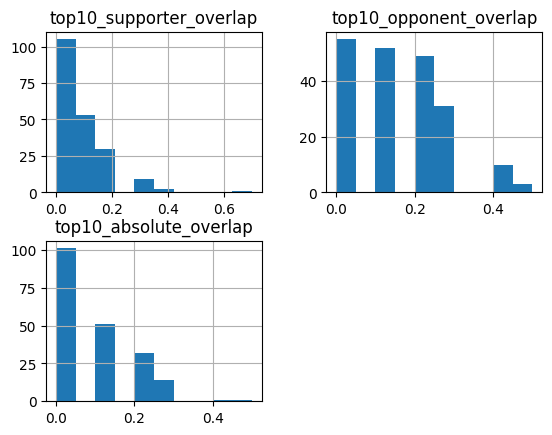

In [30]:
comparison_df[[f"top{k}_supporter_overlap", f"top{k}_opponent_overlap", f"top{k}_absolute_overlap"]].hist(bins=10)

In [31]:
summary_table = comparison_df.agg(["mean", "std", "min", "max"])

display(summary_table)

,spearman,top10_supporter_overlap,top10_opponent_overlap,top10_absolute_overlap,sign_agreement
mean,0.033019,0.077500,0.149000,0.08300,0.466475
std,0.059752,0.103912,0.126408,0.10229,0.169990
min,-0.121536,0.000000,0.000000,0.00000,0.208750
max,0.177828,0.700000,0.500000,0.50000,0.695000


# (TO REMOVE ?) BoostIn usign authors package (slower?? why??)

In [ ]:
# start = time.time()

# # Fit BoostIn explainer on your already-trained LightGBM model
# boostin_explainer = BoostIn()
# boostin_explainer.fit(
#     fitted_model,
#     X_train(),
#     y_train()
# )

# # Compute influence of every train point on every test point
# boostin_scores = boostin_explainer.get_local_influence(
#     X_test(),
#     y_test()
# )

# end = time.time()

# boostin_df = pd.DataFrame(
#     boostin_scores,
#     index=X_train.index,
#     columns=X_test.index
# )

# print("BoostIn runtime:", end - start, "seconds")
# print("Shape:", boostin_df.shape)

# #Compare results
# target_idx = X_test.index[0]

# loo_top10 = (
#     loo_df[target_idx]
#     .sort_values(ascending=False)
#     .head(10)
#     .rename("loo_score")
#     .to_frame()
# )

# boostin_top10 = (
#     boostin_df[target_idx]
#     .sort_values(ascending=False)
#     .head(10)
#     .rename("boostin_score")
#     .to_frame()
# )

# print("LOO top supporters:")
# display(loo_top10)

# print("BoostIn top supporters:")
# display(boostin_top10)

## 6. Case Study

### 6.1 Identification of Missclassified Points

In [32]:
# computing the mask to count and identified missclassified points 

fn_mask = (y_test == 1) & (y_hat_test == 0)
tp_mask = (y_test == 1)
fn_positions = np.where(fn_mask)[0]
tp_positions = np.where(tp_mask)[0]

print(f"The number of missclassified risky creditors is {len(fn_positions)}, representing {(len(fn_positions)/len(X_test))*100:.2f} % of the validation dataset and {(len(fn_positions)/len(tp_positions))*100:.2f} % of the risky creditors.")

The number of missclassified risky creditors is 20, representing 10.00 % of the validation dataset and 33.33 % of the risky creditors.


In [33]:
# visualisation of missclassified points within the dataset 

X_test[fn_mask]

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
966,23,1.0,1,1.0,2.0,1.0,2520,27,5.0
412,42,1.0,3,1.0,0.0,NaN,2292,12,0.0
858,29,0.0,2,1.0,0.0,0.0,3959,15,1.0
435,25,1.0,2,1.0,NaN,1.0,1484,12,5.0
936,28,0.0,1,1.0,0.0,2.0,745,9,5.0
647,26,0.0,2,1.0,2.0,NaN,1386,12,1.0
236,23,1.0,0,1.0,NaN,1.0,14555,6,1.0
931,22,0.0,2,1.0,0.0,1.0,1670,9,5.0
228,22,1.0,2,1.0,0.0,NaN,1478,9,5.0
308,24,0.0,2,1.0,0.0,1.0,1237,8,4.0


### 6.2 Overall Comparative Table

In [34]:
def compute_gower_distance(row_a, row_b, features_to_use, cat_cols, ranges): 
    
    per_feature_distances = []

    for feature in features_to_use: 
        value_a = row_a[feature]
        value_b = row_b[feature]

        # if feature value is NaN, pass it
        if pd.isna(value_a) or pd.isna(value_b): 
            continue 
            
        # when computing Gower's distance, categorical variables and numerical variables are treated differently as for categorical, the value is either 1 or 0 (equality or difference)
        if feature in cat_cols: 
            distance = 0.0 if value_a == value_b else 1.0
        
        # for continuous variables, the similarity between two observations for a specific feature is defined as s_ijk = 1 - |x_i - x_j| / R_k where R_k is the range of the kth variable on which similarity is computed (to normalise)
        else: 
            feature_range = ranges[feature]

            # helper to avoid inf. 
            if feature_range == 0: 
                distance == 0
            else: 
                distance = abs(value_a - value_b) / feature_range
            
        per_feature_distances.append(distance)
    
    return np.mean(per_feature_distances)

In [35]:
# Display table where columns are FN points and rows are: % of y_true == 0 in top k opponents, Gower distance between features, Gower distance focused on top 3 decreasing risk features according to SHAP

k = 5 # number of top opponents to consider while computing metrics of the table 
p = 20 # number of FN to show in the table in order to lower the dimension for visualisation

numerical_cols = [c for c in X.columns if c not in cat_cols]
feature_ranges = {c: X[c].max() - X[c].min() for c in numerical_cols} # necessary to compute Gower distance 

results = {}

for i in fn_positions[:p]: 
    test_label = X_test.index[i]
    test_row = X_test.loc[test_label]

    # get the top k opponents for each FN explored 
    top_k_opponents_index = boostin_df[test_label].sort_values(ascending=True).head(k).index

    # compute percentage of opponent with label y_true == 0
    opponents_y_true = y_train.loc[top_k_opponents_index]
    pct_y_true_0 = (opponents_y_true == 0).mean()*100

    # compute Gower's distance for each features across each opponent point on all features 
    all_features = list(X.columns)
    distances_all = []
    for opponent_index in top_k_opponents_index: 
        opponent_raw = X_train.loc[opponent_index]
        distance = compute_gower_distance(test_row, opponent_raw, all_features, cat_cols, feature_ranges) # mean distance over all feature for one opponent 
        distances_all.append(distance)
    mean_distance = np.nanmean(distances_all)

    # gather results in dic and then transform it in dataframe for each explored FN
    results[f"FN_{test_label}"] = {
        "% non-risky": round(pct_y_true_0, 1),
        "Mean Gower distance (all)": round(mean_distance, 3),
    }

table = pd.DataFrame(results) 
display(table)

,FN_966,FN_412,FN_858,FN_435,FN_936,FN_647,FN_236,FN_931,FN_228,FN_308,FN_598,FN_304,FN_190,FN_129,FN_485,FN_353,FN_182,FN_563,FN_917,FN_542
% non-risky,100.00,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000
Mean Gower distance (all),0.27,0.241,0.211,0.207,0.358,0.224,0.311,0.208,0.178,0.231,0.179,0.293,0.268,0.133,0.204,0.286,0.256,0.229,0.343,0.097


In [36]:
# Compute the three metrics randomly to compare

n_random_draws = 50
rng = np.random.default_rng(seed=42)

random_pct_y_true_0 = []
random_distance_all = []
random_distance_top3 = []

for i in fn_positions[:p]: 
    test_label = X_test.index[i]
    test_row = X_test.loc[test_label]

    shap_value_fn = shap_values_validation[i].values
    top_3_most_negative_index = np.argsort(shap_value_fn)[:3]
    top_3_most_negative = [all_features[j] for j in top_3_most_negative_index]

    for i in range(n_random_draws): 
        random_labels = rng.choice(X_train.index, size=k, replace=False)

        pct_y_true_0 = (y_train.loc[random_labels] == 0).mean()*100
        random_pct_y_true_0.append(pct_y_true_0)

        distances_all = []
        for r in random_labels: 
            distance = compute_gower_distance(test_row, X_train.loc[r], all_features, cat_cols, feature_ranges)  
            distances_all.append(distance)
        random_distance_all.append(np.nanmean(distances_all))

table['random_baseline'] = [round(np.mean(random_pct_y_true_0), 1), round(np.mean(random_distance_all), 3)]
display(table)

,FN_966,FN_412,FN_858,FN_435,FN_936,FN_647,FN_236,FN_931,FN_228,FN_308,...,FN_304,FN_190,FN_129,FN_485,FN_353,FN_182,FN_563,FN_917,FN_542,random_baseline
% non-risky,100.00,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,...,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,100.000,69.80
Mean Gower distance (all),0.27,0.241,0.211,0.207,0.358,0.224,0.311,0.208,0.178,0.231,...,0.293,0.268,0.133,0.204,0.286,0.256,0.229,0.343,0.097,0.36


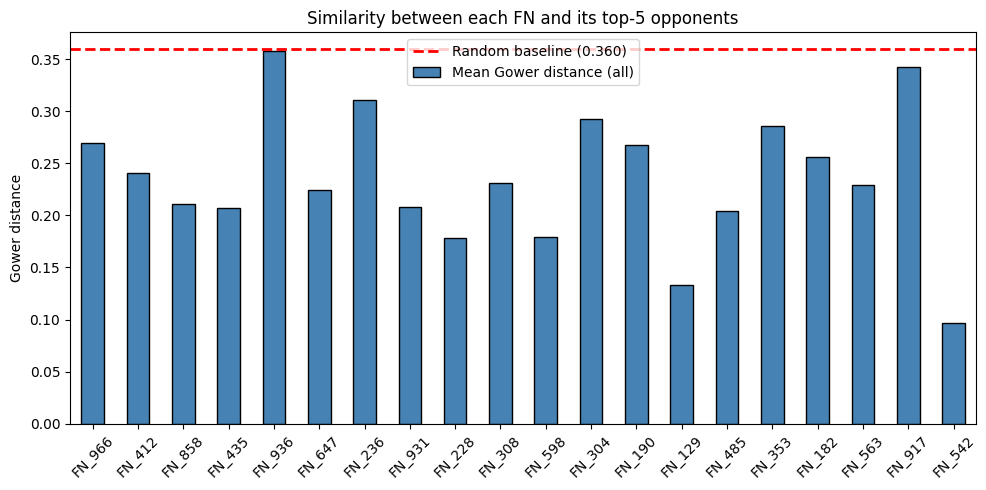

In [37]:
# Visualisation in graph 

metric = "Mean Gower distance (all)"

fn_values = table.loc[metric].drop("random_baseline").astype(float)
baseline_value = float(table.loc[metric, "random_baseline"])

fig, ax = plt.subplots(figsize=(10, 5))
fn_values.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.axhline(baseline_value, color="red", linestyle="--", linewidth=2,
           label=f"Random baseline ({baseline_value:.3f})")

ax.set_title(f"Similarity between each FN and its top-{k} opponents")
ax.set_xlabel("")
ax.set_ylabel("Gower distance")
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 BoostIn 

In [38]:
y_hat_train_s = pd.Series(y_hat_train, index=X_train.index)
y_hat_test_s  = pd.Series(y_hat_test,  index=X_test.index)

k = 5

for test_label in [858]: 
    top_k_opponents_index = boostin_df[test_label].sort_values(ascending=True).head(k).index

    comparison_table = pd.concat(
        [data.loc[top_k_opponents_index], data.loc[[test_label]]]
    ).T

    comparison_table = comparison_table.rename(index={"Risk": "y_true"})

    comparison_table.columns = (
        [f"opp_{lbl}" for lbl in top_k_opponents_index] + [f"FN_{test_label}"]
    )

    print(f"\n======= Comparative table between a missclassified test point and its top {k} most influential training points (proponents) =======")
    display(comparison_table)


======= Comparative table between a missclassified test point and its top 5 most influential training points (proponents) =======


,opp_286,opp_655,opp_31,opp_613,opp_646,FN_858
Age,26,22,27,22,32,29
Sex,male,male,male,female,male,female
Job,2,2,2,2,2,2
Housing,own,free,own,rent,own,own
Saving accounts,little,little,little,little,little,little
Checking account,little,little,little,little,little,little
Credit amount,4788,3973,4020,3632,4583,3959
Duration,48,14,24,24,30,15
Purpose,car,car,furniture/equipment,car,furniture/equipment,car
y_true,0,0,0,0,0,1


### 6.4 SHapley Additive Explanation (SHAP)
For this part, the [API of Lundberg and Lee (2017)](https://shap.readthedocs.io/en/latest/index.html) is used. 

As our project focuses on local interpretation, waterfall plot will mainly be used for the feature attribution section. Waterfall plots are specifically designed to display explanations for individual predictions. More precisely, these plots decompose a single prediction into the contribution of each feature relative to the model’s baseline prediction (Lundberg and Lee, 2017).

#### 6.4.1 Computing SHAP values

After the model training, one should compute SHAP values for the whole validation set as the goal is to get local explanation for a missclassified test point. 

In [39]:
# computing SHAP values, this results in an array of size (200,9) containing SHAP contribution of each feature for each observation. 

explainer = shap.Explainer(fitted_model)
shap_values_validation = explainer(X_test, check_additivity = False)

#### 6.4.2 Plotting Waterfall Plot for a specifc misclassified point (FN_858)

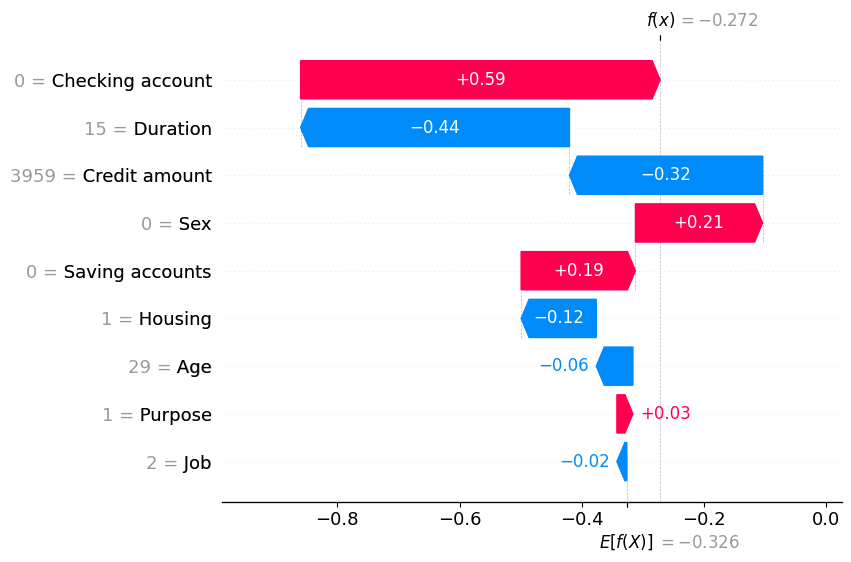

In [40]:
# Here, done for 858

i = X_test.index.get_loc(858)
shap.plots.waterfall(shap_values_validation[i])